# Paper 1 — Figures 4, 9, 10 (SVG regeneration)

**Script file:** `Paper1_Figures_4_9_10.ipynb`

**Purpose:** Figures 4, 9, and 10 in the manuscript were originally created outside this
notebook series (no source script was kept), so they only exist in the manuscript as
embedded PNG raster images. This notebook rebuilds all three **from the original field
data** (matching the manuscript's already-published statistics) and exports each as a
**true vector SVG** (with a PNG fallback for compatibility), consistent with the other
figures in the paper.

- **Figure 4** — (a) Raw PM2.5 and TPM concentrations (log-scaled y-axis) across all 32
  sites; (b) distribution of log-transformed PM2.5.
- **Figure 9** — Distribution of PM2.5 for systematic-grid vs. purposively-selected
  sites, (a) including and (b) excluding the Tab Kwang extreme value.
- **Figure 10** — Sensitivity of Getis-Ord Gi* hotspot detection to the choice of
  spatial weights specification (k-NN vs. fixed distance-band).

**สิ่งที่ต้องเตรียมก่อนรัน:** ไฟล์ `บันทึกการตรวจวัดปริมาณฝุ่น.xlsx` (ข้อมูลภาคสนามต้นฉบับ 32 จุด)
และ `site_coordinates_resolved.csv` (พิกัดที่ resolve แล้ว, ถ้ามี — ไม่มีก็ resolve ใหม่ได้ในนี้)


In [1]:
# SCRIPT: Paper1_Figures_4_9_10.ipynb
# SECTION: 0 - Setup
import sys, subprocess

def _ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

for _pkg, _imp in [("openpyxl", "openpyxl"), ("libpysal", "libpysal"), ("esda", "esda")]:
    _ensure(_pkg, _imp)

import re, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


## 1. อัปโหลดไฟล์ข้อมูลภาคสนามต้นฉบับ


In [2]:
# SCRIPT: Paper1_Figures_4_9_10.ipynb
# SECTION: 1 - Load original field measurement file
from google.colab import files
import os

FIELD_XLSX = "บันทึกการตรวจวัดปริมาณฝุ่น.xlsx"
if not os.path.exists(FIELD_XLSX):
    print(f"Upload {FIELD_XLSX}:")
    uploaded = files.upload()
    FIELD_XLSX = list(uploaded.keys())[0]

raw = pd.read_excel(FIELD_XLSX, sheet_name="Sheet1", header=0)
raw.columns = [str(c).strip() for c in raw.columns]
# first (unnamed) column holds the site id
raw = raw.rename(columns={raw.columns[0]: "site_id"})
raw = raw[raw["site_id"].notna()].reset_index(drop=True)
print(raw.shape)
raw[["site_id", "PM2.5 (µg/m3)", "TPM (µg/m3)"]].head()


Upload บันทึกการตรวจวัดปริมาณฝุ่น.xlsx:


Saving บันทึกการตรวจวัดปริมาณฝุ่น.xlsx to บันทึกการตรวจวัดปริมาณฝุ่น.xlsx
(32, 21)


,site_id,PM2.5 (µg/m3),TPM (µg/m3)
0,จุดตรวจวัดอากาศ-1,14.62,62.32
1,จุดตรวจวัดอากาศ-2,13.82,64.38
2,จุดตรวจวัดอากาศ-3,20.54,79.06
3,จุดตรวจวัดอากาศ-4,12.82,33.15
4,จุดตรวจวัดอากาศ-5,22.62,96.48


## 2. โหลดพิกัด GPS ที่ resolve แล้ว (หรือ resolve ใหม่)


In [3]:
# SCRIPT: Paper1_Figures_4_9_10.ipynb
# SECTION: 2 - Load resolved coordinates
COORDS_CSV = "site_coordinates_resolved.csv"
if not os.path.exists(COORDS_CSV):
    print(f"Upload {COORDS_CSV} (from the Paper 1 geolocation step):")
    uploaded = files.upload()
    COORDS_CSV = list(uploaded.keys())[0]

coords = pd.read_csv(COORDS_CSV)
df = raw.merge(coords, on="site_id", how="left")
missing = df["lat"].isna().sum()
print(f"Merged. Missing coordinates: {missing}/{len(df)}")
df = df.rename(columns={
    "PM2.5 (µg/m3)": "pm25",
    "TPM (µg/m3)": "tpm",
})
df["is_survey"] = df["site_id"].str.contains("survey")
df["log_pm25"] = np.log(df["pm25"])
df[["site_id", "lat", "lon", "pm25", "tpm", "is_survey"]].head()


Upload site_coordinates_resolved.csv (from the Paper 1 geolocation step):


Saving site_coordinates_resolved.csv to site_coordinates_resolved.csv
Merged. Missing coordinates: 0/32


,site_id,lat,lon,pm25,tpm,is_survey
0,จุดตรวจวัดอากาศ-1,15.132970,100.603782,14.62,62.32,False
1,จุดตรวจวัดอากาศ-2,15.132317,100.860427,13.82,64.38,False
2,จุดตรวจวัดอากาศ-3,15.131391,101.114891,20.54,79.06,False
3,จุดตรวจวัดอากาศ-4,15.130189,101.371070,12.82,33.15,False
4,จุดตรวจวัดอากาศ-5,15.128612,101.627133,22.62,96.48,False


## 3. Figure 4 — Raw PM2.5/TPM (log-scale) + distribution of log-transformed PM2.5


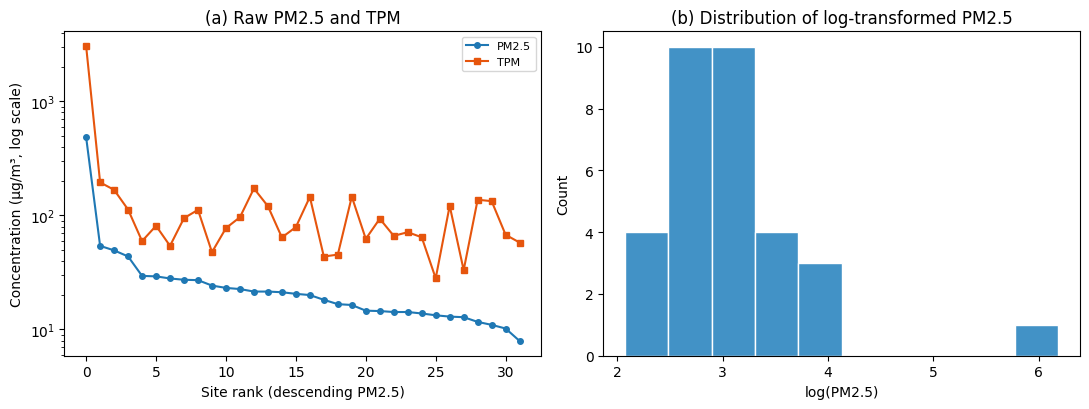

n=32, PM2.5 mean=36.00, SD=82.85, min=7.93, median=20.29, max=486.15, skew=5.51
TPM mean=184.66, SD=525.85, min=28.11, median=80.10, max=3056.74, skew=5.60
Compare these against Table 1 in the manuscript before using this figure.


In [4]:
# SCRIPT: Paper1_Figures_4_9_10.ipynb
# SECTION: 3 - Figure 4
df_sorted = df.sort_values("pm25", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.plot(range(len(df_sorted)), df_sorted["pm25"], marker="o", ms=4, color="#1f78b4", label="PM2.5")
ax.plot(range(len(df_sorted)), df_sorted["tpm"], marker="s", ms=4, color="#e6550d", label="TPM")
ax.set_yscale("log")
ax.set_xlabel("Site rank (descending PM2.5)")
ax.set_ylabel("Concentration (µg/m³, log scale)")
ax.set_title("(a) Raw PM2.5 and TPM")
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.hist(df["log_pm25"], bins=10, color="#4292c6", edgecolor="white")
ax2.set_xlabel("log(PM2.5)")
ax2.set_ylabel("Count")
ax2.set_title("(b) Distribution of log-transformed PM2.5")

plt.tight_layout()
plt.savefig("figure4_raw_pm25_tpm.svg", format="svg", bbox_inches="tight")
plt.savefig("figure4_raw_pm25_tpm.png", format="png", dpi=200, bbox_inches="tight")
plt.show()

print(f"n={len(df)}, PM2.5 mean={df['pm25'].mean():.2f}, SD={df['pm25'].std():.2f}, "
      f"min={df['pm25'].min():.2f}, median={df['pm25'].median():.2f}, max={df['pm25'].max():.2f}, "
      f"skew={df['pm25'].skew():.2f}")
print(f"TPM mean={df['tpm'].mean():.2f}, SD={df['tpm'].std():.2f}, "
      f"min={df['tpm'].min():.2f}, median={df['tpm'].median():.2f}, max={df['tpm'].max():.2f}, "
      f"skew={df['tpm'].skew():.2f}")
print("Compare these against Table 1 in the manuscript before using this figure.")


## 4. Figure 9 — Grid vs. purposive sites, with/without Tab Kwang


/tmp/ipykernel_2307/3537936913.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([grid_vals, purp_vals], labels=["Systematic-grid\n(n=%d)" % len(grid_vals),
/tmp/ipykernel_2307/3537936913.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([grid_vals, purp_vals], labels=["Systematic-grid\n(n=%d)" % len(grid_vals),


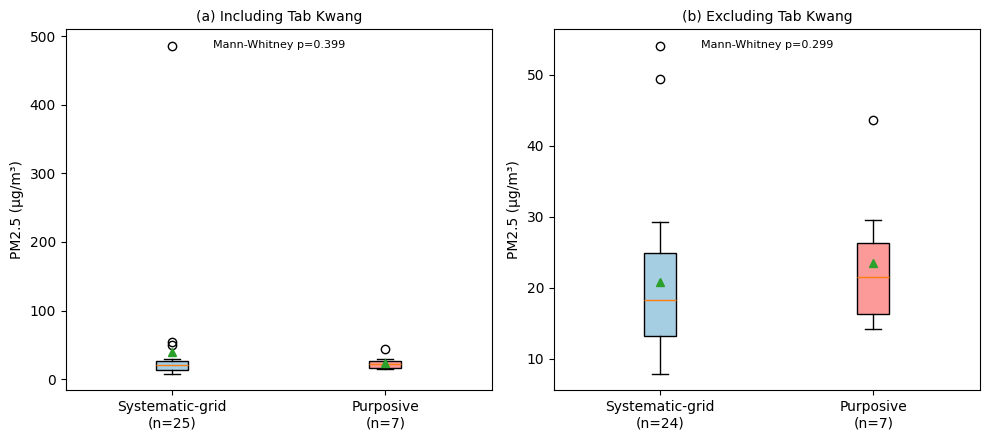

Compare medians/p-values against the manuscript text before using this figure.


In [5]:
# SCRIPT: Paper1_Figures_4_9_10.ipynb
# SECTION: 4 - Figure 9
tab_kwang_mask = df["pm25"] == df["pm25"].max()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, include_tk, title in [(axes[0], True, "(a) Including Tab Kwang"),
                                (axes[1], False, "(b) Excluding Tab Kwang")]:
    plot_df = df if include_tk else df[~tab_kwang_mask]
    grid_vals = plot_df.loc[~plot_df["is_survey"], "pm25"]
    purp_vals = plot_df.loc[plot_df["is_survey"], "pm25"]
    bp = ax.boxplot([grid_vals, purp_vals], labels=["Systematic-grid\n(n=%d)" % len(grid_vals),
                                                       "Purposive\n(n=%d)" % len(purp_vals)],
                     patch_artist=True, showmeans=True)
    for patch, color in zip(bp["boxes"], ["#a6cee3", "#fb9a99"]):
        patch.set_facecolor(color)
    ax.set_ylabel("PM2.5 (\u00b5g/m\u00b3)")
    ax.set_title(title, fontsize=10)
    u, p = stats.mannwhitneyu(grid_vals, purp_vals, alternative="two-sided")
    ax.text(0.5, 0.97, f"Mann-Whitney p={p:.3f}", transform=ax.transAxes,
            ha="center", va="top", fontsize=8)

plt.tight_layout()
plt.savefig("figure9_grid_vs_purposive.svg", format="svg", bbox_inches="tight")
plt.savefig("figure9_grid_vs_purposive.png", format="png", dpi=200, bbox_inches="tight")
plt.show()
print("Compare medians/p-values against the manuscript text before using this figure.")


## 5. Figure 10 — Sensitivity of Gi* hotspot detection to spatial weights choice


/usr/local/lib/python3.13/dist-packages/esda/getisord.py:527: RuntimeWarning: invalid value encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected_variance)
/usr/local/lib/python3.13/dist-packages/esda/getisord.py:527: RuntimeWarning: divide by zero encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected_variance)
/usr/local/lib/python3.13/dist-packages/esda/getisord.py:527: RuntimeWarning: invalid value encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected_variance)
/tmp/ipykernel_2307/1577159438.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(spec_df["spec"], rotation=30, ha="right")


                  spec  n_hotspots
            k-NN (k=3)           4
            k-NN (k=5)           3
            k-NN (k=8)           4
           k-NN (k=10)           2
 Distance-band (30 km)           4
 Distance-band (55 km)           0
 Distance-band (80 km)           0
Distance-band (110 km)           1


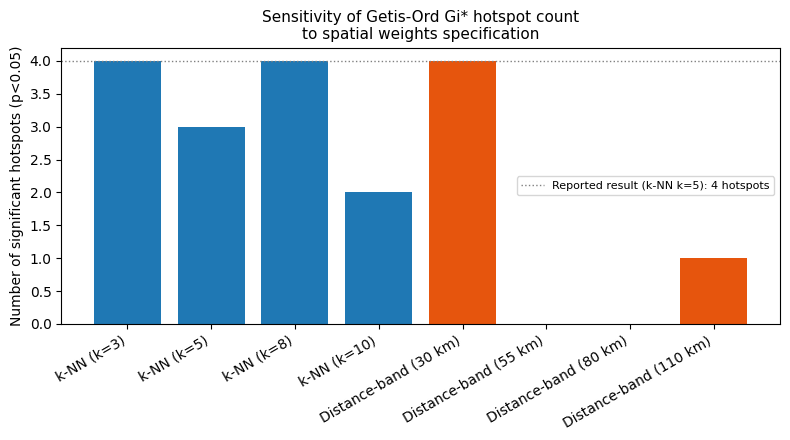

Confirm the k-NN(k=5) and distance-band(55km) bars match Table 5 in the manuscript (4 hotspots and 0 hotspots respectively) before using this figure.


In [6]:
# SCRIPT: Paper1_Figures_4_9_10.ipynb
# SECTION: 5 - Figure 10
from libpysal.weights import KNN, DistanceBand
from esda.getisord import G_Local

coords_arr = df[["lon", "lat"]].values

specs = []
for k in [3, 5, 8, 10]:
    w = KNN.from_array(coords_arr, k=k)
    w.transform = "r"
    gi = G_Local(df["log_pm25"].values, w, transform="B", permutations=999, seed=42)
    n_hot = int(((gi.Zs > 1.96) & (gi.p_sim < 0.05)).sum())
    specs.append({"spec": f"k-NN (k={k})", "n_hotspots": n_hot})

for band_km in [30, 55, 80, 110]:
    band_deg = band_km / 111.0  # approx degrees for a km threshold at this latitude
    w = DistanceBand.from_array(coords_arr, threshold=band_deg, binary=True)
    w.transform = "r"
    gi = G_Local(df["log_pm25"].values, w, transform="B", permutations=999, seed=42)
    n_hot = int(((gi.Zs > 1.96) & (gi.p_sim < 0.05)).sum())
    specs.append({"spec": f"Distance-band ({band_km} km)", "n_hotspots": n_hot})

spec_df = pd.DataFrame(specs)
print(spec_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#1f78b4"] * 4 + ["#e6550d"] * 4
ax.bar(spec_df["spec"], spec_df["n_hotspots"], color=colors)
ax.set_ylabel("Number of significant hotspots (p<0.05)")
ax.set_title("Sensitivity of Getis-Ord Gi* hotspot count\nto spatial weights specification", fontsize=11)
ax.set_xticklabels(spec_df["spec"], rotation=30, ha="right")
ax.axhline(4, color="gray", linestyle=":", linewidth=1, label="Reported result (k-NN k=5): 4 hotspots")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("figure10_gi_sensitivity.svg", format="svg", bbox_inches="tight")
plt.savefig("figure10_gi_sensitivity.png", format="png", dpi=200, bbox_inches="tight")
plt.show()
print("Confirm the k-NN(k=5) and distance-band(55km) bars match Table 5 in the manuscript "
      "(4 hotspots and 0 hotspots respectively) before using this figure.")


## ดาวน์โหลดผลลัพธ์


In [7]:
# SCRIPT: Paper1_Figures_4_9_10.ipynb
# SECTION: Download outputs
from google.colab import files as gfiles
for f in ["figure4_raw_pm25_tpm.svg", "figure4_raw_pm25_tpm.png",
          "figure9_grid_vs_purposive.svg", "figure9_grid_vs_purposive.png",
          "figure10_gi_sensitivity.svg", "figure10_gi_sensitivity.png"]:
    gfiles.download(f)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>